# Distribution Shift on BirdSet using AudioMAE embeddings

This notebook computes shift metrics between BirdSet subsets using clip-level embeddings produced by the Hugging Face AudioMAE model (see `uncertainbird/scripts/dump_audiomae_embeddings.py`). We report several complementary distances:

- MMD (RBF kernel)
- Fréchet distance (FID-style on Gaussian statistics)
- Energy distance
- Optional: entropic OT (Sinkhorn) on sampled embeddings

You can adjust the subset pairs, split (train or test), and sampling size below.

In [1]:
# Parameters
from pathlib import Path
import numpy as np
import torch

# Base directory where `dump_audiomae_embeddings.py` stored results
OUTPUT_DIR = Path("/workspace/logs/embeddings/")

# Select subset pairs and split to compare
# Example: compare Train vs Test within the same subset or compare two subsets on the same split
PAIRS = [
    ("NBP", "train", "NBP", "test"), 
    ("HSN", "train", "HSN", "test"), 
    ("NES", "train", "NES", "test"), 
    ("SNE", "train", "SNE", "test"), 
    ("SSW", "train", "SSW", "test"), 
    ("UHH", "train", "UHH", "test"), 
    ("PER", "train", "PER", "test"), 
    ("POW", "train", "POW", "test"), 
    #  same subset, train vs test
    # ("PER", "train", "NBP", "train"),  # cross-subset, same split
]

# Sampling for scalable metrics
MAX_SAMPLES_PER_DOMAIN = 2000  # clip-level embeddings per domain
RANDOM_SEED = 42

# Enable/disable OT (Sinkhorn) as it can be more expensive
ENABLE_OT = True
SINKHORN_EPS = 0.05  # entropic regularization
SINKHORN_ITERS = 200

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {DEVICE}")

Using cuda


In [2]:
# Run metrics across selected pairs
import pandas as pd

from uncertainbird.utils.distributionshift import load_clip_embeddings, sample_embeddings, mmd_rbf, energy_distance, frechet_distance, sinkhorn_ot
rows = []
for (a_subset, a_split, b_subset, b_split) in PAIRS:
    xa = load_clip_embeddings(a_subset, a_split, OUTPUT_DIR)
    xb = load_clip_embeddings(b_subset, b_split, OUTPUT_DIR)
    # sample and move to device
    xa = sample_embeddings(xa, MAX_SAMPLES_PER_DOMAIN, RANDOM_SEED).to(DEVICE)
    xb = sample_embeddings(xb, MAX_SAMPLES_PER_DOMAIN, RANDOM_SEED + 1).to(DEVICE)
    # center for some metrics stability
    with torch.no_grad():
        # ensure float32
        xa = xa.float()
        xb = xb.float()
    # compute metrics
    mmd = mmd_rbf(xa, xb)
    ed = energy_distance(xa, xb)
    try:
        fid = frechet_distance(xa, xb)
    except Exception:
        fid = float("nan")
    ot = None
    if ENABLE_OT:
        ot = sinkhorn_ot(xa, xb, eps=SINKHORN_EPS, iters=SINKHORN_ITERS)

    row = {
        "A": f"{a_subset}/{a_split}",
        "B": f"{b_subset}/{b_split}",
        "N_A": xa.shape[0],
        "N_B": xb.shape[0],
        "MMD_RBF": mmd,
        "Energy": ed,
        "Frechet": fid,
        "SinkhornOT": ot,
    }
    print(row)
    rows.append(row)

results = pd.DataFrame(rows)
results

{'A': 'NBP/train', 'B': 'NBP/test', 'N_A': 2000, 'N_B': 539, 'MMD_RBF': 0.2973947525024414, 'Energy': 0.17176955938339233, 'Frechet': -1.4424701109528542, 'SinkhornOT': nan}
{'A': 'HSN/train', 'B': 'HSN/test', 'N_A': 2000, 'N_B': 2000, 'MMD_RBF': 0.4105193614959717, 'Energy': 0.19979044795036316, 'Frechet': -1.4579378962516785, 'SinkhornOT': 172.30563354492188}
{'A': 'NES/train', 'B': 'NES/test', 'N_A': 2000, 'N_B': 2000, 'MMD_RBF': 0.12945330142974854, 'Energy': 0.05621019005775452, 'Frechet': -1.489285190589726, 'SinkhornOT': 124.84104919433594}
{'A': 'SNE/train', 'B': 'SNE/test', 'N_A': 2000, 'N_B': 2000, 'MMD_RBF': 0.2748450040817261, 'Energy': 0.11811387538909912, 'Frechet': -1.4828448072075844, 'SinkhornOT': 127.25006866455078}
{'A': 'SSW/train', 'B': 'SSW/test', 'N_A': 2000, 'N_B': 2000, 'MMD_RBF': 0.20618391036987305, 'Energy': 0.0867607444524765, 'Frechet': -1.488585527986288, 'SinkhornOT': 120.035400390625}
{'A': 'UHH/train', 'B': 'UHH/test', 'N_A': 2000, 'N_B': 2000, 'MMD_RB

,A,B,N_A,N_B,MMD_RBF,Energy,Frechet,SinkhornOT
0,NBP/train,NBP/test,2000,539,0.297395,0.171770,-1.442470,NaN
1,HSN/train,HSN/test,2000,2000,0.410519,0.199790,-1.457938,172.305634
2,NES/train,NES/test,2000,2000,0.129453,0.056210,-1.489285,124.841049
3,SNE/train,SNE/test,2000,2000,0.274845,0.118114,-1.482845,127.250069
4,SSW/train,SSW/test,2000,2000,0.206184,0.086761,-1.488586,120.035400
5,UHH/train,UHH/test,2000,2000,0.100418,0.046710,-1.489778,130.546677
6,PER/train,PER/test,2000,2000,0.193066,0.086585,-1.475079,147.155106
7,POW/train,POW/test,2000,2000,0.120833,0.043585,-1.495816,102.498413


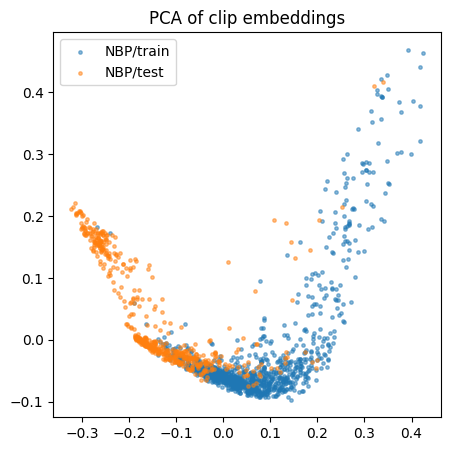

In [3]:
# Optional: quick 2D PCA visualization for one pair
try:
    import sklearn.decomposition as skd
    HAS_SK = True
except Exception:
    HAS_SK = False

if HAS_SK and len(PAIRS) > 0:
    a_subset, a_split, b_subset, b_split = PAIRS[0]
    xa = load_clip_embeddings(a_subset, a_split, OUTPUT_DIR)
    xb = load_clip_embeddings(b_subset, b_split, OUTPUT_DIR)
    xa = sample_embeddings(xa, 1000, RANDOM_SEED).numpy()
    xb = sample_embeddings(xb, 1000, RANDOM_SEED + 1).numpy()
    X = np.concatenate([xa, xb], axis=0)
    y = np.array([0] * xa.shape[0] + [1] * xb.shape[0])
    pca = skd.PCA(n_components=2)
    Z = pca.fit_transform(X)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(5,5))
    plt.scatter(Z[y==0,0], Z[y==0,1], s=6, alpha=0.5, label=f"{a_subset}/{a_split}")
    plt.scatter(Z[y==1,0], Z[y==1,1], s=6, alpha=0.5, label=f"{b_subset}/{b_split}")
    plt.legend()
    plt.title("PCA of clip embeddings")
    plt.show()
else:
    print("sklearn not available or no pairs configured; skipping PCA plot.")

## Class wise

Calculate metrics for each bird species class separately and then average the results.


In [4]:
# Compute class-wise shift metrics per pair (only for pairs within the same subset where label spaces match)
import pandas as pd

from uncertainbird.utils.distributionshift import load_embeddings_and_labels, mmd_rbf, energy_distance, frechet_distance, sinkhorn_ot

MIN_PER_CLASS = 20
MAX_PER_CLASS = 500
SEED_CLASS = 123
ENABLE_OT_CLASSWISE = False

def per_class_metrics_for_pair(a_subset: str, a_split: str, b_subset: str, b_split: str,
                               min_per_class: int = MIN_PER_CLASS,
                               max_per_class: int = MAX_PER_CLASS,
                               seed: int = SEED_CLASS):
    embA, labA = load_embeddings_and_labels(a_subset, a_split, OUTPUT_DIR)
    embB, labB = load_embeddings_and_labels(b_subset, b_split, OUTPUT_DIR)

    if labA is None or labB is None:
        raise ValueError("Labels not found in embeddings bundles; re-run dump script with labels included.")
    if labA.shape[1] != labB.shape[1]:
        raise ValueError(f"Label dimension mismatch: {labA.shape[1]} vs {labB.shape[1]}. Class-wise comparison requires matching spaces.")

    # Ensure alignment: class spaces must be the same (works best for same subset across splits)
    num_classes = labA.shape[1]

    rng = torch.Generator().manual_seed(seed)

    rows = []
    for c in range(num_classes):
        idxA = (labA[:, c] > 0).nonzero(as_tuple=True)[0]
        idxB = (labB[:, c] > 0).nonzero(as_tuple=True)[0]
        nA = idxA.numel()
        nB = idxB.numel()
        if nA < min_per_class or nB < min_per_class:
            continue
        if nA > max_per_class:
            idxA = idxA[torch.randperm(nA, generator=rng)[:max_per_class]]
            nA = idxA.numel()
        if nB > max_per_class:
            idxB = idxB[torch.randperm(nB, generator=rng)[:max_per_class]]
            nB = idxB.numel()

        xa = embA[idxA].to(DEVICE).float()
        xb = embB[idxB].to(DEVICE).float()

        mmd = mmd_rbf(xa, xb)
        ed = energy_distance(xa, xb)
        try:
            fid = frechet_distance(xa, xb)
        except Exception:
            fid = float("nan")
        ot = None
        if ENABLE_OT_CLASSWISE:
            ot = sinkhorn_ot(xa, xb, eps=SINKHORN_EPS, iters=SINKHORN_ITERS)

        rows.append({
            "class_id": c,
            "N_A": int(nA),
            "N_B": int(nB),
            "MMD_RBF": mmd,
            "Energy": ed,
            "Frechet": fid,
            "SinkhornOT": ot,
        })

    df = pd.DataFrame(rows).sort_values(by="MMD_RBF", ascending=False, ignore_index=True)
    macro = {
        "class_id": "<macro>",
        "N_A": int(df["N_A"].sum()) if not df.empty else 0,
        "N_B": int(df["N_B"].sum()) if not df.empty else 0,
        "MMD_RBF": float(df["MMD_RBF"].mean()) if not df.empty else float("nan"),
        "Energy": float(df["Energy"].mean()) if not df.empty else float("nan"),
        "Frechet": float(df["Frechet"].mean()) if not df.empty else float("nan"),
        "SinkhornOT": float(df["SinkhornOT"].mean()) if (ENABLE_OT_CLASSWISE and not df["SinkhornOT"].isna().all()) else None,
    }
    return df, pd.Series(macro)


# Run for configured pairs and show summary + top classes by MMD
pair_summaries = []
per_pair_top = {}
for (a_subset, a_split, b_subset, b_split) in PAIRS:
    try:
        df_c, macro = per_class_metrics_for_pair(a_subset, a_split, b_subset, b_split)
    except Exception as e:
        print(f"Skipping {a_subset}/{a_split} vs {b_subset}/{b_split}: {e}")
        continue
    macro = macro.to_dict()
    macro.update({"A": f"{a_subset}/{a_split}", "B": f"{b_subset}/{b_split}", "classes_used": int(df_c.shape[0])})
    pair_summaries.append(macro)
    per_pair_top[f"{a_subset}/{a_split}__{b_subset}/{b_split}"] = df_c.head(10)

summary_df = pd.DataFrame(pair_summaries)
summary_df, per_pair_top

(  class_id    N_A    N_B   MMD_RBF    Energy   Frechet SinkhornOT          A  \
 0  <macro>  11500    608  0.308925  0.190292 -1.444982       None  NBP/train   
 1  <macro>   4893   3026  0.407500  0.209025 -1.449121       None  HSN/train   
 2  <macro>  21591   8347  0.172196  0.084175 -1.479287       None  NES/train   
 3  <macro>  17761   9612  0.307240  0.131710 -1.479627       None  SNE/train   
 4  <macro>  29080  19158  0.223976  0.095175 -1.484456       None  SSW/train   
 5  <macro>   6014   5437  0.148498  0.075141 -1.481350       None  UHH/train   
 6  <macro>  39067  20918  0.225764  0.106654 -1.469860       None  PER/train   
 7  <macro>  15184   7244  0.154780  0.056500 -1.494936       None  POW/train   
 
           B  classes_used  
 0  NBP/test            23  
 1  HSN/test            12  
 2  NES/test            54  
 3  SNE/test            36  
 4  SSW/test            59  
 5  UHH/test            18  
 6  PER/test            95  
 7  POW/test            31  ,
 {'NBP/

## Calculate metrics on waveforms directly

Use the BirdSet datamodule to get random waveform samples from each subset incl. peak normalization and than compute MDD and Energy distance directly on the waveforms.

### Data loading

In [ ]:
from birdset.datamodule.birdset_datamodule import BirdSetDataModule
from birdset.datamodule.base_datamodule import (
        DatasetConfig,
        BirdSetTransformsWrapper,
    )
from birdset.datamodule.components.transforms import PreprocessingConfig
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch

# subset_names = ["NBP"]
subset_names = ["NBP", "HSN", "NES", "SNE", "SSW", "UHH", "PER", "POW"]
data_dir = "/workspace/data_birdset/"
num_workers = 1
max_samples = 2000

data = {}

for subset_name in subset_names:
    data[subset_name] = {}
    dm = BirdSetDataModule(
        dataset=DatasetConfig(
            data_dir=data_dir,
            hf_path="DBD-research-group/BirdSet",
            hf_name=subset_name,
            n_workers=num_workers,
            val_split=0.0001,
            task="multilabel",
            classlimit=None,
            eventlimit=None,
            sample_rate=16_000,
        ),
        transforms=BirdSetTransformsWrapper(
            sample_rate=16_000,
            model_type="waveform",
            preprocessing=PreprocessingConfig(
                normalize_waveform='instance_peak_normalization',
            ),
        ),
    )
    dm.prepare_data()
    dm.setup('fit')
    dm.setup('test')
    datasets = {"train": dm.train_dataset, "test": dm.test_dataset}

    for split_name, ds in datasets.items():
        if ds is None or len(ds) == 0:
            print(f"Warning: No samples for subset {subset_name} split {split_name}. Skipping.")
            continue

        dl = DataLoader(
            ds,
            batch_size=1,
            shuffle=True,
            num_workers=num_workers,
        )
        waveforms = []
        labels = []
        i = 0
        for batch in tqdm(dl, desc=f"Dataset {subset_name} Split {split_name}"):
            waveforms.append(batch['input_values'].squeeze(0))  # remove batch dim
            labels.append(batch['labels'].squeeze(0))
            i += 1
            if (i) >= max_samples:
                break
        waveforms = torch.stack(waveforms, dim=0)
        labels = torch.stack(labels, dim=0)
        data[subset_name][split_name] = {
            "waveforms": waveforms,
            "labels": labels,
        }
        print(f"Loaded {waveforms.shape[0]} waveforms for subset {subset_name} split {split_name}.")
data


Dataset NBP Split train:   0%|          | 0/186121 [00:00<?, ?it/s]2025-11-06 14:01:32.813345: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/workspace/.venv/lib/python3.10/site-packages/birdset/datamodule/components/transforms.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype=torch.float16)
Dataset NBP Split train:   1%|          | 1999/186121 [00:32<49:58, 61.41it/s]  


Loaded 2000 waveforms for subset NBP split train.


Dataset NBP Split test:   0%|          | 0/539 [00:00<?, ?it/s]2025-11-06 14:02:05.266595: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/workspace/.venv/lib/python3.10/site-packages/birdset/datamodule/components/transforms.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype=torch.float16)
Dataset NBP Split test: 100%|██████████| 539/539 [00:06<00:00, 78.08it/s] 


Loaded 539 waveforms for subset NBP split test.


{'NBP': {'train': {'waveforms': tensor([[[-0.0138, -0.0187, -0.0109,  ..., -0.0041, -0.0013, -0.0026]],
   
           [[ 0.0073,  0.0094,  0.0090,  ..., -0.0130, -0.0141, -0.0069]],
   
           [[ 0.0039,  0.0039, -0.0014,  ...,  0.0038, -0.0017, -0.0019]],
   
           ...,
   
           [[ 0.0039,  0.0015,  0.0037,  ..., -0.0124, -0.0168,  0.0092]],
   
           [[ 0.0007, -0.0027, -0.0107,  ...,  0.0245, -0.0128, -0.0264]],
   
           [[ 0.0073,  0.0226, -0.0165,  ..., -0.0237, -0.0247,  0.0012]]]),
   'labels': tensor([[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]], dtype=torch.float16)},
  'test': {'waveforms': tensor([[[ 1.2218e-01,  2.0789e-01,  1.7631e-01,  ...,  6.4237e-06,
              6.4237e-06,  6.4237e-06]],
   
           [[ 4.3854e-02,  2.2112e

Dataset NES Split test:   8%|█████████▎                                                                                                        | 1999/24480 [00:25<04:47, 78.09it/s]


Loaded 2000 waveforms for subset NES split test.


Extracting train split:   0%|          | 0/21 [00:00<?, ?it/s]

In [31]:
data.keys()

dict_keys(['NBP', 'HSN', 'NES', 'SNE', 'SSW', 'UHH', 'PER', 'POW'])

In [10]:
# save data to disk for later use
import torch
torch.save(data, "/workspace/data_birdset/processed_birdset_waveforms_labels.pt")

### Compute MMD and Energy distance on waveforms

In [21]:
data['NBP'].keys()

dict_keys(['train', 'test', 'mmd_rbf_train_test'])

In [13]:
from uncertainbird.utils.distributionshift import energy_distance, mmd_rbf
for subset in data.keys():
    for split in ["train", "test"]:
        print(f"Processing subset {subset} split {split}")
        waveforms = data[subset][split]["waveforms"]
        labels = data[subset][split]["labels"]
        print(f"Subset {subset} Split {split}: Waveforms shape: {waveforms.shape}, Labels shape: {labels.shape}")
    # distance between train and test splits
    if "train" in data[subset] and "test" in data[subset]:
        x_train = data[subset]["train"]["waveforms"].float()
        x_test = data[subset]["test"]["waveforms"].float()
        # x_train/test shape: (N, 1, T) -> (N, T)
        if x_train.dim() == 3 and x_train.size(1) == 1:
            x_train = x_train.squeeze(1)
        if x_test.dim() == 3 and x_test.size(1) == 1:
            x_test = x_test.squeeze(1)
        # check if shapes align otherwise use the min length
        min_length = min(x_train.shape[0], x_test.shape[0])
        x_train = x_train[:min_length]
        x_test = x_test[:min_length]
        ed = energy_distance(x_train, x_test)
        print(f"Subset {subset}: Energy distance between train and test waveforms: {ed}")
        data[subset]["energy_distance_train_test"] = ed
        # mmd
        mmd = mmd_rbf(x_train, x_test)
        print(f"Subset {subset}: MMD RBF between train and test waveforms: {mmd}")
        data[subset]["mmd_rbf_train_test"] = mmd

Processing subset NBP split train
Subset NBP Split train: Waveforms shape: torch.Size([2000, 1, 80000]), Labels shape: torch.Size([2000, 51])
Processing subset NBP split test
Subset NBP Split test: Waveforms shape: torch.Size([539, 1, 80000]), Labels shape: torch.Size([539, 51])
Subset NBP: Energy distance between train and test waveforms: 0.14758968353271484
Subset NBP: MMD RBF between train and test waveforms: 0.004423737525939941
Processing subset HSN split train
Subset HSN Split train: Waveforms shape: torch.Size([2000, 1, 80000]), Labels shape: torch.Size([2000, 21])
Processing subset HSN split test
Subset HSN Split test: Waveforms shape: torch.Size([2000, 1, 80000]), Labels shape: torch.Size([2000, 21])
Subset HSN: Energy distance between train and test waveforms: 0.9764404296875
Subset HSN: MMD RBF between train and test waveforms: 0.030070185661315918
Processing subset NES split train
Subset NES Split train: Waveforms shape: torch.Size([2000, 1, 80000]), Labels shape: torch.Siz

In [ ]:
# compute per class energy and mmd within each subset between train and test
MIN_PER_CLASS = 20
from uncertainbird.utils.distributionshift import energy_distance, mmd_rbf, compute_metric_per_class
for subset in data.keys():
    if "train" in data[subset] and "test" in data[subset]:
        print(f"Processing per-class metrics for subset {subset}")
        waveforms_train = data[subset]["train"]["waveforms"].squeeze(1).float()
        labels_train = data[subset]["train"]["labels"]
        waveforms_test = data[subset]["test"]["waveforms"].squeeze(1).float()
        labels_test = data[subset]["test"]["labels"]
        per_class_ed = compute_metric_per_class(
            waveforms_train,
            labels_train,
            waveforms_test,
            labels_test,
            metric_fn=energy_distance,
            min_per_class=MIN_PER_CLASS,
        )
        per_class_mmd = compute_metric_per_class(
            waveforms_train,
            labels_train,
            waveforms_test,
            labels_test,
            metric_fn=mmd_rbf,
            min_per_class=MIN_PER_CLASS,
        )
        data[subset]["per_class_energy_distance_train_test"] = per_class_ed
        data[subset]["per_class_mmd_rbf_train_test"] = per_class_mmd
        print(f"Subset {subset}: Energy Distance: {per_class_ed:.4f}, MMD RBF: {per_class_mmd:.4f}")


Processing per-class metrics for subset NBP
Subset NBP: Computed per-class energy distance and MMD RBF between train and test waveforms.
Processing per-class metrics for subset HSN
Subset HSN: Computed per-class energy distance and MMD RBF between train and test waveforms.
Processing per-class metrics for subset NES
Subset NES: Computed per-class energy distance and MMD RBF between train and test waveforms.
Processing per-class metrics for subset SNE
Subset SNE: Computed per-class energy distance and MMD RBF between train and test waveforms.
Processing per-class metrics for subset SSW
Subset SSW: Computed per-class energy distance and MMD RBF between train and test waveforms.
Processing per-class metrics for subset UHH
Subset UHH: Computed per-class energy distance and MMD RBF between train and test waveforms.
Processing per-class metrics for subset PER
Subset PER: Computed per-class energy distance and MMD RBF between train and test waveforms.
Processing per-class metrics for subset P

In [34]:
data['NBP'].keys()

dict_keys(['train', 'test', 'energy_distance_train_test', 'mmd_rbf_train_test', 'model_performance', 'per_class_energy_distance_train_test', 'per_class_mmd_rbf_train_test'])

In [17]:
# add the cmap metric for each model to the data object
# add model performance numbers from the table to the `data` dict
models_perf = {
    "ConvNeXt (OT)": {
        "POW": 0.47, "PER": 0.25, "NES": 0.34, "UHH": 0.24,
        "HSN": 0.46, "NBP": 0.68, "SSW": 0.37, "SNE": 0.31, "Score": 0.38,
    },
    "ConvNeXt (AT-E)": {
        "POW": 0.54, "PER": 0.29, "NES": 0.37, "UHH": 0.23,
        "HSN": 0.43, "NBP": 0.68, "SSW": 0.41, "SNE": 0.32, "Score": 0.39,
    },
    "ConvNeXt (AT-O)": {
        "POW": 0.56, "PER": 0.31, "NES": 0.39, "UHH": 0.23,
        "HSN": 0.47, "NBP": 0.69, "SSW": 0.44, "SNE": 0.34, "Score": 0.41,
    },
    "AudioProtoPNet (OT)": {
        "POW": 0.49, "PER": 0.25, "NES": 0.36, "UHH": 0.25,
        "HSN": 0.46, "NBP": 0.68, "SSW": 0.37, "SNE": 0.30, "Score": 0.38,
    },
    "AudioProtoPNet (AT-E)": {
        "POW": 0.57, "PER": 0.30, "NES": 0.38, "UHH": 0.26,
        "HSN": 0.48, "NBP": 0.69, "SSW": 0.41, "SNE": 0.32, "Score": 0.41,
    },
    "AudioProtoPNet (AT-O)": {
        "POW": 0.59, "PER": 0.32, "NES": 0.40, "UHH": 0.25,
        "HSN": 0.50, "NBP": 0.68, "SSW": 0.44, "SNE": 0.35, "Score": 0.42,
    },
}

subsets = ["POW", "PER", "NES", "UHH", "HSN", "NBP", "SSW", "SNE"]

for subset in subsets:
    if subset not in data:
        data[subset] = {}
    # ensure there is a dedicated container for model scores
    data[subset].setdefault("model_performance", {})
    for model_name, perf_map in models_perf.items():
        # store the per-subset score (float) and overall score under model entry
        data[subset]["model_performance"][model_name] = {
            "subset_score": float(perf_map[subset]),
            "overall_score": float(perf_map["Score"]),
        }

print("Inserted model performance entries for subsets:", ", ".join(subsets))

Inserted model performance entries for subsets: POW, PER, NES, UHH, HSN, NBP, SSW, SNE


In [18]:
# compute the relative perfomance improbement from audioprotopnet (OT) to audiorotopnet (AT-O)
for subset in subsets:
    apn_ot_score = data[subset]["model_performance"]["AudioProtoPNet (OT)"]["subset_score"]
    apn_at_o_score = data[subset]["model_performance"]["AudioProtoPNet (AT-O)"]["subset_score"]
    rel_improvement = (apn_at_o_score - apn_ot_score) / apn_ot_score if apn_ot_score != 0 else float("nan")
    data[subset]["model_performance"]["AudioProtoPNet (AT-O)"]["relative_improvement_over_OT"] = rel_improvement
    print(f"Subset {subset}: Relative improvement AudioProtoPNet (AT-O) over (OT): {rel_improvement:.4f}")

Subset POW: Relative improvement AudioProtoPNet (AT-O) over (OT): 0.2041
Subset PER: Relative improvement AudioProtoPNet (AT-O) over (OT): 0.2800
Subset NES: Relative improvement AudioProtoPNet (AT-O) over (OT): 0.1111
Subset UHH: Relative improvement AudioProtoPNet (AT-O) over (OT): 0.0000
Subset HSN: Relative improvement AudioProtoPNet (AT-O) over (OT): 0.0870
Subset NBP: Relative improvement AudioProtoPNet (AT-O) over (OT): 0.0000
Subset SSW: Relative improvement AudioProtoPNet (AT-O) over (OT): 0.1892
Subset SNE: Relative improvement AudioProtoPNet (AT-O) over (OT): 0.1667


### Visualization

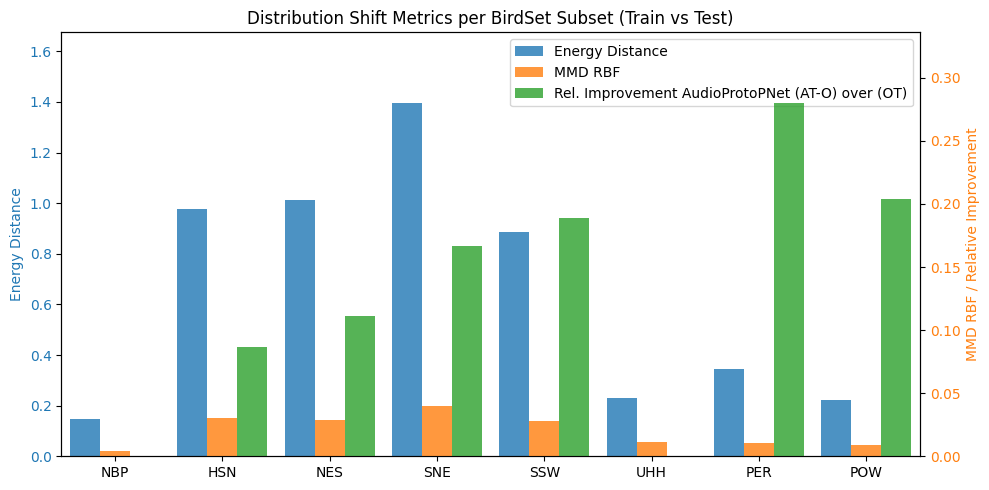

In [23]:
# make a bar plot of the computed metrics per subset
subsets = list(data.keys())
energy_distances = [data[subset].get("energy_distance_train_test", 0) for subset in subsets]
mmd_values = [data[subset].get("mmd_rbf_train_test", 0) for subset in subsets]
rel_improvements = [
    data[subset]["model_performance"]["AudioProtoPNet (AT-O)"]["relative_improvement_over_OT"]
    for subset in subsets
]

fig, ax1 = plt.subplots(figsize=(10, 5))
width = 0.35
gap = 0.2
group_width = 3 * width + gap
x = np.arange(len(subsets)) * group_width

color1 = "C0"
bars1 = ax1.bar(x - width, energy_distances, width, label="Energy Distance", color=color1, alpha=0.8)
ax1.set_ylabel("Energy Distance", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.set_xticks(x)
ax1.set_xticklabels(subsets)
ax1.set_ylim(0, max(energy_distances) * 1.2)
ax1.set_xlim(x[0] - group_width / 2, x[-1] + group_width / 2)

ax2 = ax1.twinx()
color2 = "C1"
bars2 = ax2.bar(x, mmd_values, width, label="MMD RBF", color=color2, alpha=0.8)
bars3 = ax2.bar(
    x + width,
    rel_improvements,
    width,
    label="Rel. Improvement AudioProtoPNet (AT-O) over (OT)",
    color="C2",
    alpha=0.8,
)

lower = min(0, min(mmd_values), min(rel_improvements))
upper = max(max(mmd_values), max(rel_improvements))
ax2.set_ylabel("MMD RBF / Relative Improvement", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)
ax2.set_ylim(lower * 1.2, upper * 1.2 if upper > 0 else 0.1)

plt.title("Distribution Shift Metrics per BirdSet Subset (Train vs Test)")

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right")

fig.tight_layout()
plt.show()

ValueError: Axis limits cannot be NaN or Inf

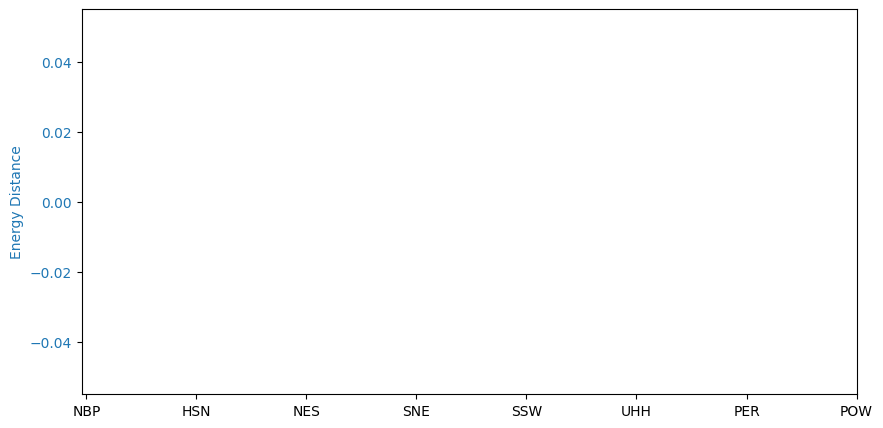

In [35]:
# make a bar plot of the computed metrics per subset
subsets = list(data.keys())
energy_distances = [data[subset].get("per_class_energy_distance_train_test", 0) for subset in subsets]
mmd_values = [data[subset].get("per_class_mmd_rbf_train_test", 0) for subset in subsets]
rel_improvements = [
    data[subset]["model_performance"]["AudioProtoPNet (AT-O)"]["relative_improvement_over_OT"]
    for subset in subsets
]

fig, ax1 = plt.subplots(figsize=(10, 5))
width = 0.35
gap = 0.2
group_width = 3 * width + gap
x = np.arange(len(subsets)) * group_width

color1 = "C0"
bars1 = ax1.bar(x - width, energy_distances, width, label="Energy Distance", color=color1, alpha=0.8)
ax1.set_ylabel("Energy Distance", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.set_xticks(x)
ax1.set_xticklabels(subsets)
ax1.set_ylim(0, max(energy_distances) * 1.2)
ax1.set_xlim(x[0] - group_width / 2, x[-1] + group_width / 2)

ax2 = ax1.twinx()
color2 = "C1"
bars2 = ax2.bar(x, mmd_values, width, label="MMD RBF", color=color2, alpha=0.8)
bars3 = ax2.bar(
    x + width,
    rel_improvements,
    width,
    label="Rel. Improvement AudioProtoPNet (AT-O) over (OT)",
    color="C2",
    alpha=0.8,
)

lower = min(0, min(mmd_values), min(rel_improvements))
upper = max(max(mmd_values), max(rel_improvements))
ax2.set_ylabel("MMD RBF / Relative Improvement", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)
ax2.set_ylim(lower * 1.2, upper * 1.2 if upper > 0 else 0.1)

plt.title("Distribution Shift Metrics per BirdSet Subset (Train vs Test)")

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right")

fig.tight_layout()
plt.show()

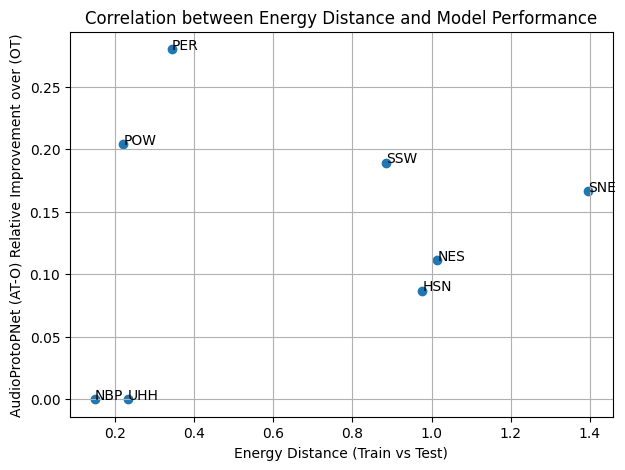

In [21]:
# plott the correlation between energy distance and performance improvement
import matplotlib.pyplot as plt
subsets = list(data.keys()) 
energy_distances = [data[subset].get("energy_distance_train_test", 0) for subset in subsets]
performance_improvements = [
    data[subset]["model_performance"]["AudioProtoPNet (AT-O)"]["relative_improvement_over_OT"]
    for subset in subsets
]
plt.figure(figsize=(7,5))
plt.scatter(energy_distances, performance_improvements)
for i, subset in enumerate(subsets):
    plt.annotate(subset, (energy_distances[i], performance_improvements[i]))
plt.xlabel("Energy Distance (Train vs Test)")
plt.ylabel("AudioProtoPNet (AT-O) Relative Improvement over (OT)")
plt.title("Correlation between Energy Distance and Model Performance")
plt.grid()
plt.show()

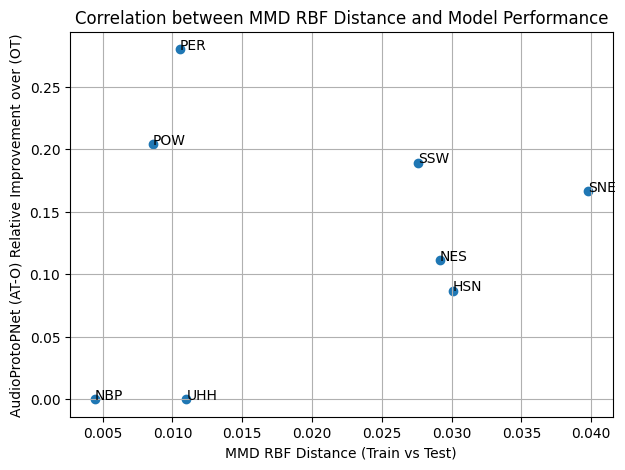

In [22]:
# plott the correlation between mmd distance and performance improvement
import matplotlib.pyplot as plt
subsets = list(data.keys())
mmd_distances = [data[subset].get("mmd_rbf_train_test", 0) for subset in subsets]
performance_improvements = [
    data[subset]["model_performance"]["AudioProtoPNet (AT-O)"]["relative_improvement_over_OT"]
    for subset in subsets
]
plt.figure(figsize=(7,5))
plt.scatter(mmd_distances, performance_improvements)
for i, subset in enumerate(subsets):
    plt.annotate(subset, (mmd_distances[i], performance_improvements[i]))
plt.xlabel("MMD RBF Distance (Train vs Test)")
plt.ylabel("AudioProtoPNet (AT-O) Relative Improvement over (OT)")
plt.title("Correlation between MMD RBF Distance and Model Performance")
plt.grid()
plt.show()
